In [1]:
pip install pandas plotly nbformat nbclient ipywidgets matplotlib "urllib3<2"

You should consider upgrading via the '/Users/stripura/Desktop/ocp-workload-analysis-/venv/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


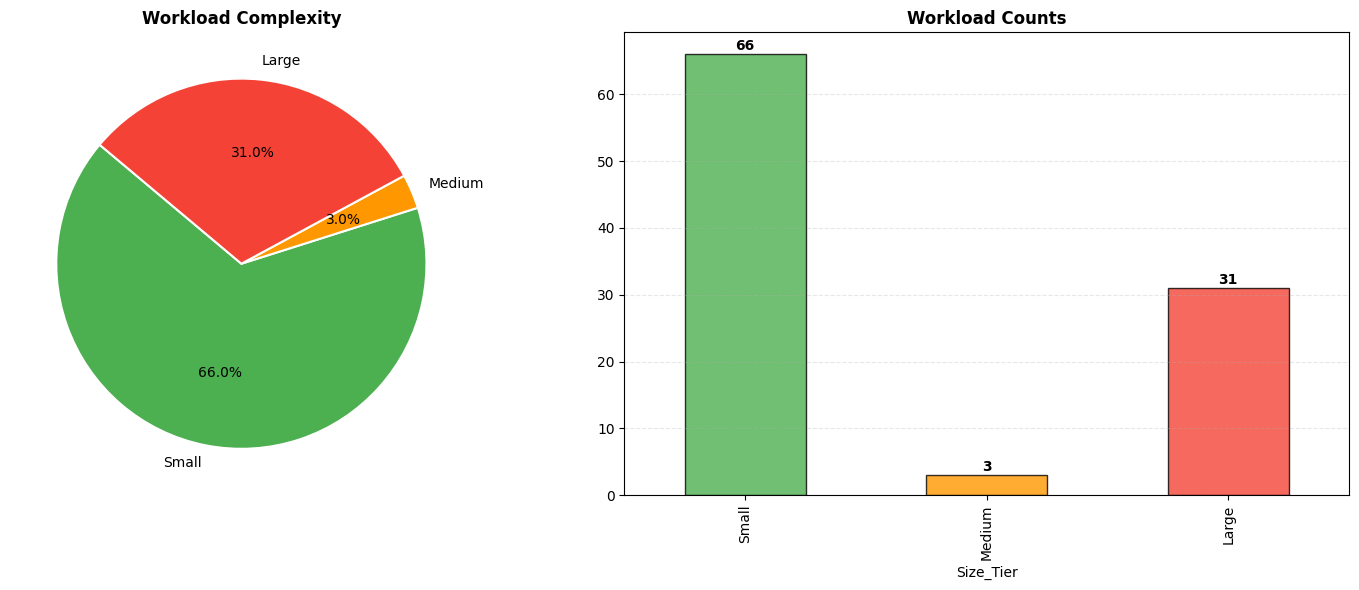

✅ Success! Results saved to current directory as: outputs/graded_k8s_sample_100_rows.csv


In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import os

# --- 1. RESOURCE PARSERS ---

def parse_cpu(cpu_str):
    if pd.isna(cpu_str) or str(cpu_str) == '0' or str(cpu_str) == 'None': return 0.1
    cpu_str = str(cpu_str).lower()
    if cpu_str.endswith('m'): return int(cpu_str[:-1]) / 1000
    try: return float(cpu_str)
    except: return 0.1

def parse_mem(mem_str):
    if pd.isna(mem_str) or str(mem_str) == '0' or str(mem_str) == 'None': return 128
    mem_str = str(mem_str).lower()
    if 'gi' in mem_str: return float(mem_str.replace('gi', '')) * 1024
    if 'mi' in mem_str: return float(mem_str.replace('mi', ''))
    try: return float(mem_str) / (1024**2)
    except: return 128

# --- 2. CONFIG LOADER ---

def load_config(file_path='configs/workload_complexity_config.json'):
    # Default config if file doesn't exist
    default_cfg = {
        "weights": {"cpu_high": 3, "cpu_med": 1, "mem_high": 3, "mem_med": 1, "pvc_presence": 4, "net_complexity": 2},
        "thresholds": {"cpu_high": 2.0, "cpu_med": 0.5, "mem_high": 4096, "mem_med": 1024, "net_ports": 2, "tier_large": 7, "tier_medium": 3}
    }
    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            return json.load(f)
    return default_cfg

# --- 3. THE TIERING LOGIC (Using Config) ---

def assign_tier(row, cfg):
    score = 0
    w, t = cfg["weights"], cfg["thresholds"]
    
    # CPU & Mem logic
    if row.get('cpu_val', 0) >= t["cpu_high"]: score += w["cpu_high"]
    elif row.get('cpu_val', 0) >= t["cpu_med"]: score += w["cpu_med"]
    if row.get('mem_val', 0) >= t["mem_high"]: score += w["mem_high"]
    elif row.get('mem_val', 0) >= t["mem_med"]: score += w["mem_med"]
    
    # Extra weights
    if row.get('PVC_Count', 0) > 0: score += w["pvc_presence"]
    if row.get('Network_Interfaces_Ports', 1) > t["net_ports"]: score += w["net_complexity"]

    if score >= t["tier_large"]: return 'Large'
    if score >= t["tier_medium"]: return 'Medium'
    return 'Small'

# --- 4. THE DASHBOARD GENERATOR ---

def create_complex_dashboard(df, cfg_name="Default"):
    tier_order = ['Small', 'Medium', 'Large']
    counts = df['Size_Tier'].value_counts().reindex(tier_order, fill_value=0)
    colors = ['#4CAF50', '#FF9800', '#F44336']
    
    fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Pie
    counts.plot(kind='pie', ax=ax_pie, autopct='%1.1f%%', colors=colors, startangle=140,
                wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax_pie.set_title(f"Workload Complexity", fontweight='bold')
    ax_pie.set_ylabel('')

    # Bar
    counts.plot(kind='bar', ax=ax_bar, color=colors, edgecolor='black', alpha=0.8)
    ax_bar.set_title("Workload Counts", fontweight='bold')
    ax_bar.grid(axis='y', linestyle='--', alpha=0.3)
    
    for i, v in enumerate(counts):
        ax_bar.text(i, v + (max(counts)*0.01), str(v), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- 5. MAIN EXECUTION LOOP ---

def run_analysis(csv_file, config_file='configs/workload_complexity_config.json'):
    # Load Data
    df = pd.read_csv(csv_file)
    cfg = load_config(config_file)
    
    # Process
    df['cpu_val'] = df['CPU_Limit'].apply(parse_cpu)
    df['mem_val'] = df['Mem_Limit'].apply(parse_mem)
    df['Size_Tier'] = df.apply(lambda x: assign_tier(x, cfg), axis=1)
    
    # Display
    create_complex_dashboard(df, config_file)

    #Save graded file
    base_filename = os.path.basename(csv_file)
    output_name = f"outputs/graded_{base_filename}"
    
    try:
        df.to_csv(output_name, index=False)
        print(f"✅ Success! Results saved to current directory as: {output_name}")
    except Exception as e:
        print(f"❌ Error saving CSV: {e}")

# To run it, just call:
run_analysis('sample_data/k8s_sample_100_rows.csv')


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. THE NAMESPACE GRADING FUNCTION
def assign_ns_tier(row):
    score = 0
    
    # Workload Count (Deployments + StatefulSets)
    workloads = row.get('Deployments', 0) + row.get('StatefulSets', 0)
    score += (workloads * 1)
    
    # Pod Density
    pods = row.get('Pods', 0)
    score += (pods * 0.5)
    
    # Storage Complexity (PVCs)
    pvcs = row.get('PVCs', 0)
    score += (pvcs * 3)
    
    # Networking & Security Overhead
    net_ops = row.get('NetworkPolicies', 0) + row.get('Ingress', 0)
    score += (net_ops * 2)

    # Final Namespace Grading
    # Adjust these thresholds based on your cluster size
    if score >= 50:
        return 'Large'
    elif score >= 15:
        return 'Medium'
    else:
        return 'Small'

# 2. THE NAMESPACE DASHBOARD HELPER
def create_ns_complexity_dashboard(df):
    """
    Standardized helper to generate Pie and Bar charts for Namespaces.
    """
    # Apply the Tiering Logic
    df['NS_Complexity_Tier'] = df.apply(assign_ns_tier, axis=1)
    
    # Prepare Data
    tier_order = ['Small', 'Medium', 'Large']
    counts = df['NS_Complexity_Tier'].value_counts().reindex(tier_order, fill_value=0)
    colors = ['#8BC34A', '#2196F3', '#673AB7'] # Different color palette (Green, Blue, Purple)
    
    # Setup Figure
    fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(16, 7))
    
    # --- PIE CHART ---
    counts.plot(kind='pie', ax=ax_pie, autopct='%1.1f%%', colors=colors, startangle=140,
                wedgeprops={'edgecolor': 'white', 'linewidth': 2}, textprops={'fontweight': 'bold'})
    ax_pie.set_title('Namespace Complexity Share', fontsize=14, pad=15)
    ax_pie.set_ylabel('')

    # --- BAR CHART ---
    counts.plot(kind='bar', ax=ax_bar, color=colors, edgecolor='black', alpha=0.8)
    ax_bar.set_title('Namespace Counts by Tier', fontsize=14, pad=15)
    ax_bar.set_xlabel('Namespace Complexity', fontsize=12)
    ax_bar.set_ylabel('Number of Namespaces', fontsize=12)
    ax_bar.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add labels
    for i, v in enumerate(counts):
        ax_bar.text(i, v + (max(counts) * 0.02), str(v), ha='center', fontweight='bold')

    plt.suptitle('Kubernetes Namespace Complexity Analysis', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()



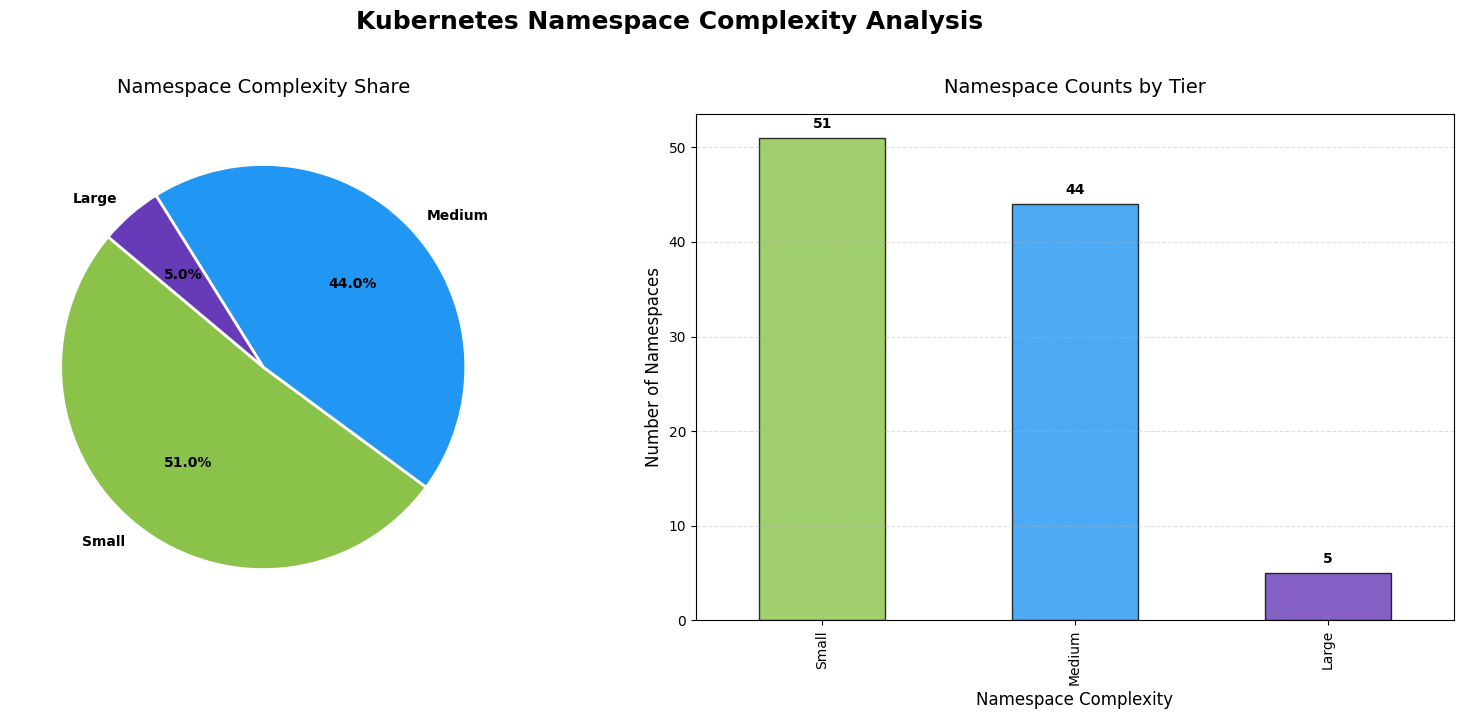

In [4]:
# --- HOW TO RUN ---
df_ns = pd.read_csv('sample_data/k8s_ns_100_sample.csv')
create_ns_complexity_dashboard(df_ns)